### Warehouse/Retail ML Project (Regression Model):

#### 1. Main Idea:

. To predict the futures retail sales (or warehouse sales) based on historical data.

. Forecast next month's retail sales peach item.

. Estimate warehouse demand for each supplier/item.

. Identify seasonal trends (e.g., sales spikes in December).

. Target output to predict being Retail Sale. 

#### 2. Train vs Test Data:

. Training data use records up to a certain point like 2018-2023.

. Testing data use more recent records from 2024-2025.

. Alt: Can use train/test split.

#### 3. Algorithm:

. Linear Regression.

. Decision Tree Regression.

. Random Forest Regression.

#### 4. Expected Results:

. A model that Predicts Next Month's Retail Sale Per Item.

. Evaluation metrics: 
MAE (Mean Absolute Error): Average error in uits.
RMSE(Root Mean Squared Error): Penalizes large errors.
R^2 score: How much variance in sale is explained by the model.

. Eg: MAE = 120 units -> on average, your predictions are off by 1200 sales units.

. Eg: R^2 = 0.75 -> model explains 75% of the variation in sales.

In [24]:
import pandas as pd

# Import the CSV file
Warehouseretail = pd.read_csv(
    "Warehouse_and_Retail_Sales.csv",
    encoding = "ISO-8859-1", 
    low_memory=False
)

🔎 Step 1: Inspect the dataset
- Look at the first few rows (Warehouseretail.head()).
- Check column types (Warehouseretail.info()).
- Get summary statistics (Warehouseretail.describe()).

👉 This tells you if columns are numeric, categorical, or mixed — and whether anything looks off


In [25]:
# Quick look at the data
Warehouseretail.head(5)       # first 5 rows

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2017,4,ROYAL WINE CORP,100200,GAMLA CAB - 750ML,WINE,0.0,1.0,0.0
1,2017,4,SANTA MARGHERITA USA INC,100749,SANTA MARGHERITA P/GRIG ALTO - 375ML,WINE,0.0,1.0,0.0
2,2017,4,JIM BEAM BRANDS CO,10103,KNOB CREEK BOURBON 9YR - 100P - 375ML,LIQUOR,0.0,8.0,0.0
3,2017,4,HEAVEN HILL DISTILLERIES INC,10120,J W DANT BOURBON 100P - 1.75L,LIQUOR,0.0,2.0,0.0
4,2017,4,ROYAL WINE CORP,101664,RAMON CORDOVA RIOJA - 750ML,WINE,0.0,4.0,0.0


In [26]:
Warehouseretail.info()      # column types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128355 entries, 0 to 128354
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              128355 non-null  int64  
 1   MONTH             128355 non-null  int64  
 2   SUPPLIER          128331 non-null  object 
 3   ITEM CODE         128355 non-null  object 
 4   ITEM DESCRIPTION  128355 non-null  object 
 5   ITEM TYPE         128354 non-null  object 
 6   RETAIL SALES      128355 non-null  float64
 7   RETAIL TRANSFERS  128355 non-null  float64
 8   WAREHOUSE SALES   128355 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 8.8+ MB


In [27]:
Warehouseretail.describe()   # summary statistics for numeric columns

,YEAR,MONTH,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
count,128355.000000,128355.000000,128355.000000,128355.000000,128355.000000
mean,2017.206030,7.079303,6.563037,7.188161,22.624213
std,0.404454,3.645826,28.924944,30.640156,239.693277
min,2017.000000,1.000000,-6.490000,-27.660000,-4996.000000
25%,2017.000000,5.000000,0.000000,0.000000,0.000000
50%,2017.000000,8.000000,0.330000,0.000000,1.000000
75%,2017.000000,10.000000,3.250000,4.000000,4.000000
max,2018.000000,12.000000,1616.600000,1587.990000,16271.750000


In [28]:
print(Warehouseretail.describe())


                YEAR          MONTH   RETAIL SALES  RETAIL TRANSFERS  \
count  128355.000000  128355.000000  128355.000000     128355.000000   
mean     2017.206030       7.079303       6.563037          7.188161   
std         0.404454       3.645826      28.924944         30.640156   
min      2017.000000       1.000000      -6.490000        -27.660000   
25%      2017.000000       5.000000       0.000000          0.000000   
50%      2017.000000       8.000000       0.330000          0.000000   
75%      2017.000000      10.000000       3.250000          4.000000   
max      2018.000000      12.000000    1616.600000       1587.990000   

       WAREHOUSE SALES  
count    128355.000000  
mean         22.624213  
std         239.693277  
min       -4996.000000  
25%           0.000000  
50%           1.000000  
75%           4.000000  
max       16271.750000  


In [29]:
print("Dataset shape:", Warehouseretail.shape)

Dataset shape: (128355, 9)


In [30]:
# Missing values per column
Warehouseretail.isnull().sum()

# Out of 128, 355 rows, only 24 have no supplier listed = 0.018% missing value

YEAR                 0
MONTH                0
SUPPLIER            24
ITEM CODE            0
ITEM DESCRIPTION     0
ITEM TYPE            1
RETAIL SALES         0
RETAIL TRANSFERS     0
WAREHOUSE SALES      0
dtype: int64

In [31]:
# Check for duplicate: Tell you if row are repeated.
Warehouseretail.duplicated().sum()

np.int64(0)

In [32]:
# Unqiues Values in categorical Columns: 
# helps you see how many categories you’ll need to encode later.
Warehouseretail['SUPPLIER'].nunique()

333

In [33]:
# Range of sale values: confirms if numbers are reasonable (e.g., no negatives).
Warehouseretail['ITEM TYPE'].nunique()

8

In [34]:
# Drop the 24 rows without missing supplier:
Warehouseretail = Warehouseretail.dropna(subset=['SUPPLIER'])

In [35]:
# Range of sale value:
# confirms if numbers are reasonable (e.g., no negatives)
Warehouseretail['RETAIL SALES'].min(), Warehouseretail['RETAIL SALES'].max()

(-6.49, 1616.6)

In [36]:
# Range for Warehouse Sales
Warehouseretail['WAREHOUSE SALES'].min(), Warehouseretail['WAREHOUSE SALES'].max()

(-4996.0, 16271.75)

In [37]:
# Range for Retail Transfers
Warehouseretail['RETAIL TRANSFERS'].min(), Warehouseretail['RETAIL TRANSFERS'].max()

(-27.66, 1587.99)

#### 🧹 Interpretation of Ranges
- Retail Sales: (-6.49, 1616.6)
→ Mostly positive, but a few small negatives. Likely returns or corrections.

- Warehouse Sales: (-4996.0, 16271.75)
→ Much larger scale than retail sales. The negatives are significant — probably representing inventory adjustments, returns, or accounting entries. You’ll need to decide whether to keep them or clean them.

- Retail Transfers: (-27.66, 1587.99)
→ Similar to retail sales, mostly positive but with small negatives. Again, likely returns or corrections.

- Negative values:
- If negatives represent returns, you might keep them (they’re part of reality).
- If they’re errors, you could set them to 0 or drop those rows.
- Best practice: check how frequent they are. If rare, dropping or clipping to 0 is fine


In [38]:
# Option: clip negatives to 0
Warehouseretail['RETAIL SALES'] = Warehouseretail['RETAIL SALES'].clip(lower=0)
Warehouseretail['WAREHOUSE SALES'] = Warehouseretail['WAREHOUSE SALES'].clip(lower=0)
Warehouseretail['RETAIL TRANSFERS'] = Warehouseretail['RETAIL TRANSFERS'].clip(lower=0)

In [39]:
# Check the impact of clipping.
(Warehouseretail[['RETAIL SALES','WAREHOUSE SALES','RETAIL TRANSFERS']] < 0).sum()

RETAIL SALES        0
WAREHOUSE SALES     0
RETAIL TRANSFERS    0
dtype: int64

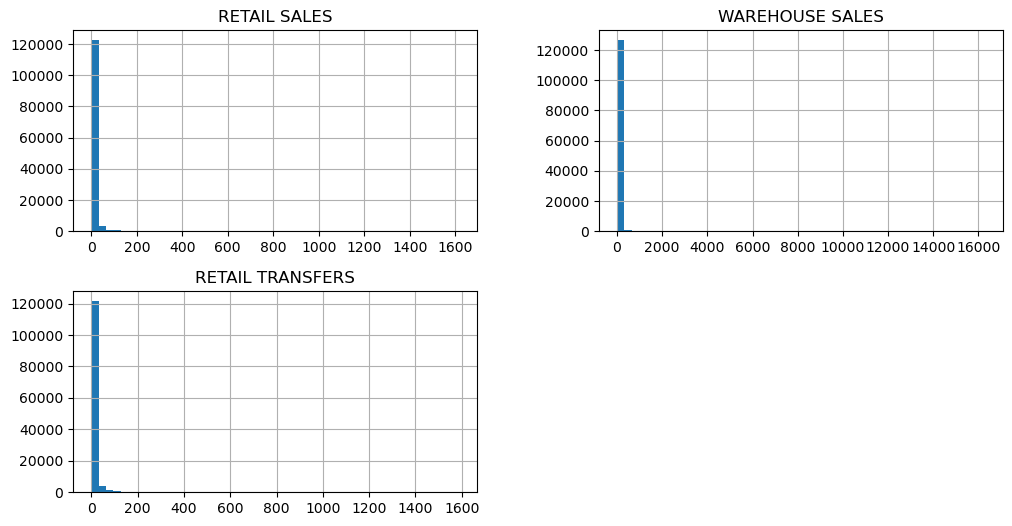

In [40]:
# Visualize Distributions:
import matplotlib.pyplot as plt

Warehouseretail[['RETAIL SALES','WAREHOUSE SALES','RETAIL TRANSFERS']].hist(bins=50, figsize=(12,6))
plt.show()

In [41]:
# Create time Index: Year + Month into a proper "DATE" Column.
Warehouseretail['DATE'] = pd.to_datetime(Warehouseretail[['YEAR','MONTH']].assign(DAY=1))
Warehouseretail = Warehouseretail.sort_values('DATE')

In [42]:
# Define target: Shift retail sale forward one month to create the prediction target:
Warehouseretail['TARGET'] = Warehouseretail.groupby('ITEM CODE')['RETAIL SALES'].shift(-1)

In [43]:
# Splits data into train and test: Train on earlier years, test on later years.
train = Warehouseretail[Warehouseretail['DATE'] < '2024-01-01']
test = Warehouseretail[Warehouseretail['DATE'] >= '2024-01-01']